In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("=== Dataset Info ===")
print(f"Total Transactions: {len(df)}")
print(f"Fraud Cases: {df['Class'].sum()}")
print(f"Normal Cases: {len(df) - df['Class'].sum()}")
print(f"Fraud Percentage: {df['Class'].mean()*100:.4f}%")
print("\nMissing Values:", df.isnull().sum().sum())

=== Dataset Info ===
Total Transactions: 284807
Fraud Cases: 492
Normal Cases: 284315
Fraud Percentage: 0.1727%

Missing Values: 0


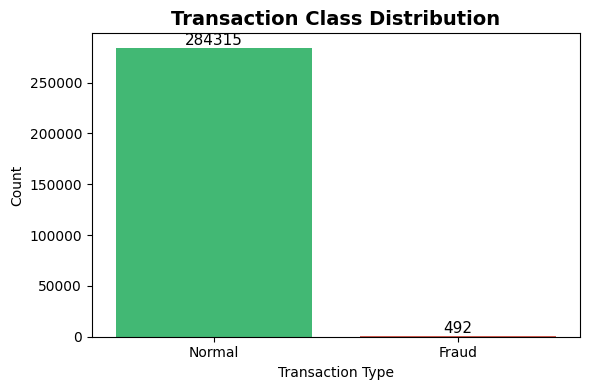

✅ Plot saved!


In [4]:
os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Class', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Transaction Class Distribution', fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/fraud_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

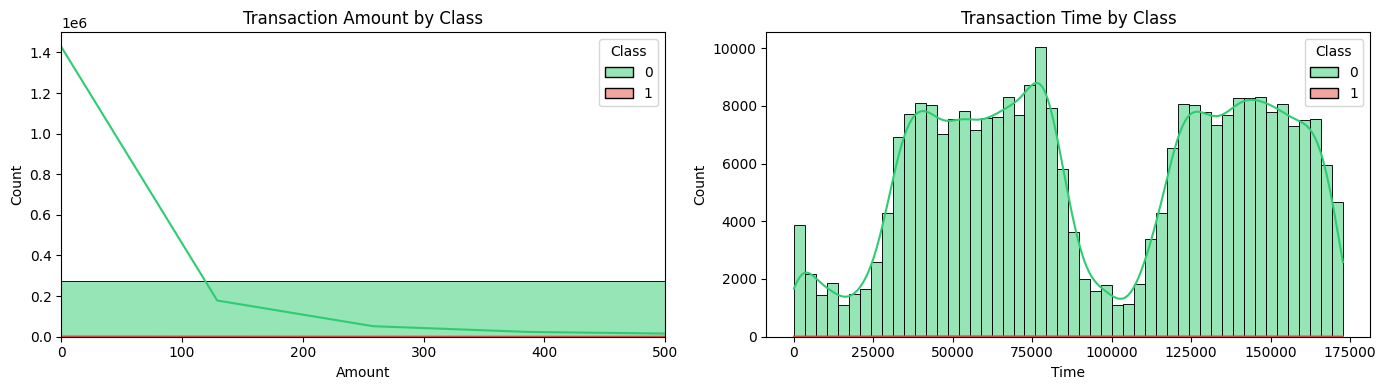

✅ Plot saved!


In [5]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution
sns.histplot(data=df, x='Amount', hue='Class', bins=50,
             palette=['#2ecc71','#e74c3c'], ax=axes[0], kde=True)
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlim(0, 500)

# Time distribution
sns.histplot(data=df, x='Time', hue='Class', bins=50,
             palette=['#2ecc71','#e74c3c'], ax=axes[1], kde=True)
axes[1].set_title('Transaction Time by Class')

plt.tight_layout()
plt.savefig('../outputs/amount_time_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Amount aur Time scale karo
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Original columns drop karo
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Features aur Target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Preprocessing done!")
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nFraud in train: {y_train.sum()}")
print(f"Fraud in test:  {y_test.sum()}")

✅ Preprocessing done!
Train size: (227845, 30)
Test size:  (56962, 30)

Fraud in train: 394
Fraud in test:  98


In [7]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print("\n✅ SMOTE applied! Classes balanced.")

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

✅ SMOTE applied! Classes balanced.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 45)
print("       RANDOM FOREST RESULTS")
print("=" * 45)
print(f"ROC-AUC Score    : {roc_auc_score(y_test, rf_prob):.4f}")
print(f"Avg Precision    : {average_precision_score(y_test, rf_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Normal','Fraud']))
print("✅ Random Forest trained!")

       RANDOM FOREST RESULTS
ROC-AUC Score    : 0.9800
Avg Precision    : 0.7964

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.42      0.85      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.92      0.78     56962
weighted avg       1.00      1.00      1.00     56962

✅ Random Forest trained!


In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 45)
print("         XGBOOST RESULTS")
print("=" * 45)
print(f"ROC-AUC Score    : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"Avg Precision    : {average_precision_score(y_test, xgb_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Normal','Fraud']))
print("✅ XGBoost trained!")

         XGBOOST RESULTS
ROC-AUC Score    : 0.9769
Avg Precision    : 0.8547

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.29      0.89      0.43        98

    accuracy                           1.00     56962
   macro avg       0.64      0.94      0.72     56962
weighted avg       1.00      1.00      1.00     56962

✅ XGBoost trained!


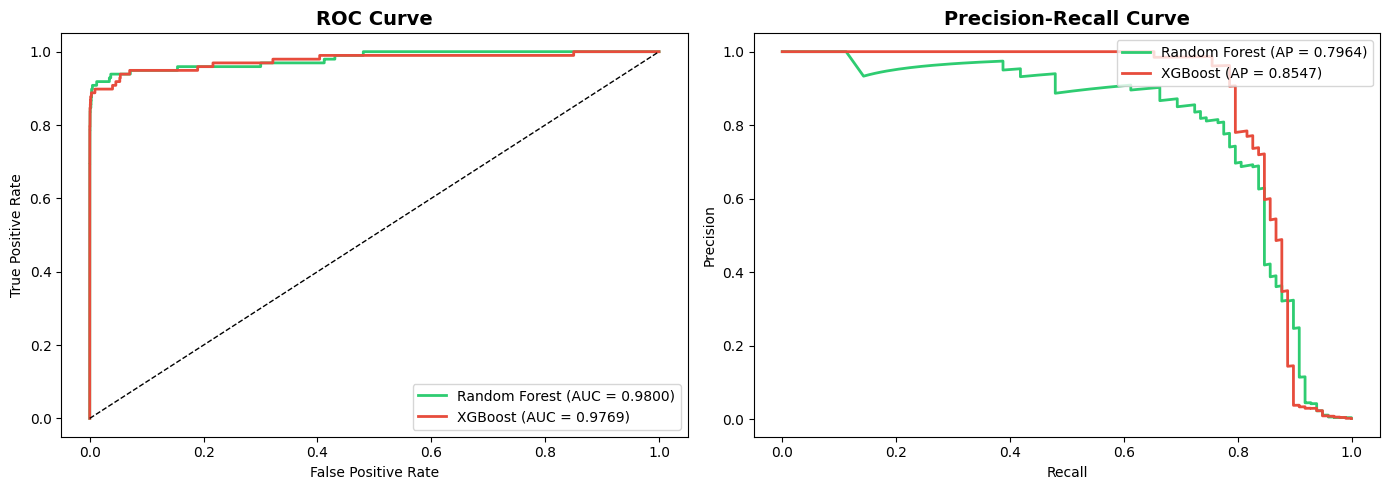

✅ Curves saved!


In [10]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

axes[0].plot(rf_fpr, rf_tpr, color='#2ecc71', lw=2,
             label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})')
axes[0].plot(xgb_fpr, xgb_tpr, color='#e74c3c', lw=2,
             label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_prob)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_prob)

axes[1].plot(rf_rec, rf_prec, color='#2ecc71', lw=2,
             label=f'Random Forest (AP = {average_precision_score(y_test, rf_prob):.4f})')
axes[1].plot(xgb_rec, xgb_prec, color='#e74c3c', lw=2,
             label=f'XGBoost (AP = {average_precision_score(y_test, xgb_prob):.4f})')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/roc_pr_curves.png', dpi=150)
plt.show()
print("✅ Curves saved!")

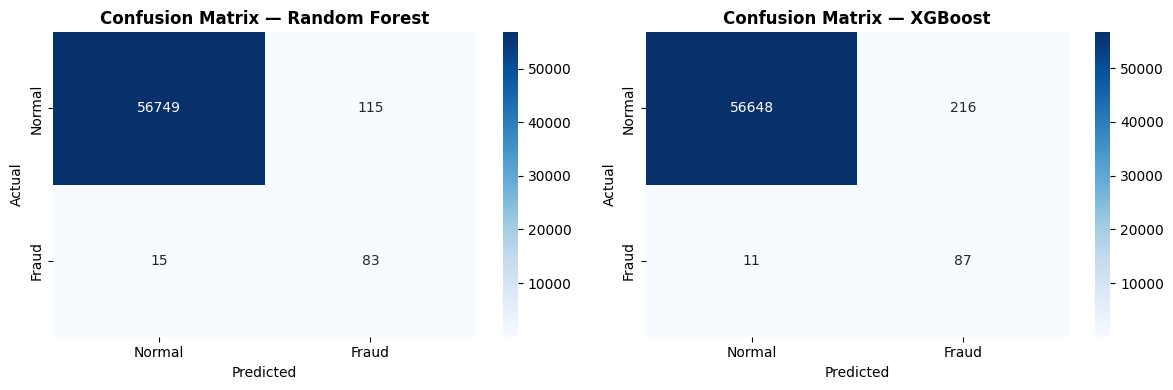

✅ Confusion Matrices saved!


In [11]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in zip(axes,
                            [rf_pred, xgb_pred],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fraud'],
                yticklabels=['Normal','Fraud'])
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion Matrices saved!")

Background dataset has 454902 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=454902 when initializing the masker.
100%|===================| 56819/56962 [05:50<00:00]        

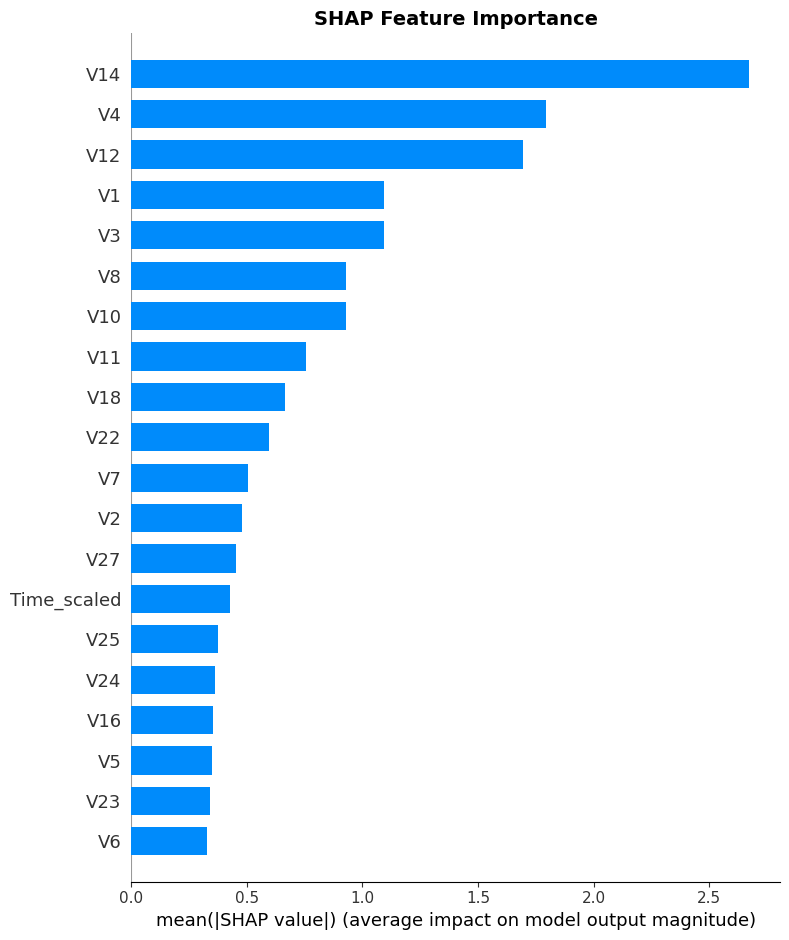

✅ SHAP Bar plot saved!


In [12]:
import shap
os.makedirs('../outputs', exist_ok=True)

explainer = shap.Explainer(xgb_model, X_train_sm)
shap_values = explainer(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Bar plot saved!")

In [13]:
import joblib
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

print("✅ Models saved!")

✅ Models saved!


In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("=" * 50)
print("   CREDIT CARD FRAUD DETECTION — FINAL RESULTS")
print("=" * 50)

print("\n📊 RANDOM FOREST:")
print(f"   ROC-AUC        : {roc_auc_score(y_test, rf_prob):.4f}")
print(f"   Avg Precision  : {average_precision_score(y_test, rf_prob):.4f}")
print(f"   F1-Score(Fraud): {f1_score(y_test, rf_pred):.4f}")
print(f"   Precision      : {precision_score(y_test, rf_pred):.4f}")
print(f"   Recall         : {recall_score(y_test, rf_pred):.4f}")

print("\n📊 XGBOOST:")
print(f"   ROC-AUC        : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"   Avg Precision  : {average_precision_score(y_test, xgb_prob):.4f}")
print(f"   F1-Score(Fraud): {f1_score(y_test, xgb_pred):.4f}")
print(f"   Precision      : {precision_score(y_test, xgb_pred):.4f}")
print(f"   Recall         : {recall_score(y_test, xgb_pred):.4f}")

print("\n✅ Project Complete!")
print("=" * 50)

   CREDIT CARD FRAUD DETECTION — FINAL RESULTS

📊 RANDOM FOREST:
   ROC-AUC        : 0.9800
   Avg Precision  : 0.7964
   F1-Score(Fraud): 0.5608
   Precision      : 0.4192
   Recall         : 0.8469

📊 XGBOOST:
   ROC-AUC        : 0.9769
   Avg Precision  : 0.8547
   F1-Score(Fraud): 0.4339
   Precision      : 0.2871
   Recall         : 0.8878

✅ Project Complete!
